# Sanity Checks\n
Load the generated manifest and inspect average rolling correlation over time.

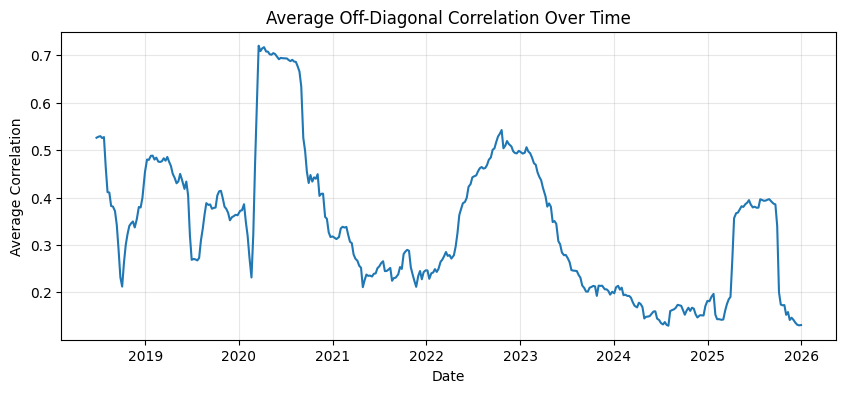

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

manifest = pd.read_csv('../outputs/manifests/matrix_index.csv', parse_dates=['date'])
avg_corr = []
for _, row in manifest.iterrows():
    corr = np.load('../' + row['corr_path'])
    n = corr.shape[0]
    if n < 2:
        avg_corr.append(np.nan)
        continue
    mask = ~np.eye(n, dtype=bool)
    avg_corr.append(float(np.mean(corr[mask])))

plt.figure(figsize=(10, 4))
plt.plot(manifest['date'], avg_corr)
plt.title('Average Off-Diagonal Correlation Over Time')
plt.xlabel('Date')
plt.ylabel('Average Correlation')
plt.grid(alpha=0.3)

plt.show()